In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d
from sklearn.neighbors import KernelDensity
import matplotlib.patheffects as path_effects

from data_models import TeacherStudentModel, MNISTDataModel, MixtureClassificationModel, MNISTMergedDataModel, MixtureClassificationModelGaussian, MNISTMergedDataModelGaussian
from losses_regularizers import LogisticLoss, QuadraticRegularizer
from erm_theory import ERMTrainer, TheoryFixedPointSolver

# =========================
# CONFIGURE FIGURE VISIBILITY AND STYLING
# =========================
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 22,
    'legend.fontsize': 14,
    'lines.linewidth': 3,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'axes.facecolor': '#f9f9f9',
    'figure.facecolor': '#f9f9f9',
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial'],
})

# Custom color palette
colors = {
    'class_0': '#1f77b4',
    'class_1': '#ff7f0e',
    'theoretical': '#d62728',
    'gaussian': '#7f7f7f',
    'empirical': '#2ca02c',
    'background': '#f9f9f9',
    'grid': '#e0e0e0',
}

# ============================================================
# TEACHER–STUDENT MODEL
# ============================================================
teacher = 'multi'
if teacher == 'teacher':
    rng = np.random.default_rng(0)
    c = 5
    n_train = c * 10
    p = c * 15
    mu = np.zeros(p)
    mu[0] = 3.0
    C = 0.2**2 * np.eye(p)
    theta_star = np.zeros(p)
    theta_star[0] = 1.0
    model = TeacherStudentModel(
        p=p,
        mu_x=mu,
        C_x=C,
        feature_dist="uniform_iid",
        y_model="sign",
        theta_teacher=theta_star,
        noise_std=0.1,
    )
    classes = [1, -1]
    
elif teacher == 'multi':
    n_train = 60
    classes = [1, 0]
    p = 100  # Dimensionality of features
    K = 2   # Number of classes (class 0 and class 1)

    # Proportions for each class (uniform)
    gamma = [0.4, 0.6]

    # Means for each class
    mus = [-1.2*np.ones(p)/np.sqrt(p), 1.2*np.ones(p)/np.sqrt(p)]  # Class 0 has mean at origin, class 1 at (1,1,...)

    # Covariance matrices for each class (using diagonal matrices for simplicity)
    covs = [0.1 * np.eye(p), 0.1 * np.eye(p)]  # Small variances for simplicity

    # Sub-mode deltas for bimodal distribution (to create distinct sub-modes for each class)
    sub_mode_deltas = [np.ones(p) * 0.15, np.ones(p) * 0.1]  # Large separation between sub-modes for both classes

    # Define the feature distribution (non-Gaussian)
    feature_dist = "uniform_iid"  # This ensures non-Gaussian features

    # Instantiate the MixtureClassificationModel
    model = MixtureClassificationModel(
        p=p,
        gamma=gamma,
        mus=mus,
        covs=covs,
        sub_mode_deltas=sub_mode_deltas,  # Bimodal separation for both classes
        feature_dist=feature_dist
    )
    model_gaussian = MixtureClassificationModelGaussian(
        p=p,
        gamma=gamma,
        mus=mus,
        covs=covs,
        sub_mode_deltas=sub_mode_deltas,  # Bimodal separation for both classes
        feature_dist=feature_dist
    )
elif teacher == 'merged_mnist':
    n_train = 60
    W_downsample = create_downsampling_matrix(m)

    model = MNISTMergedDataModel(
        data_path="mnist.npz",  # Path to the MNIST data file
        task="binary",                      # Binary classification (2 classes: 0 and 1)
        classes=[0, 1],                     # Class 0 is (3, 6) and Class 1 is (4, 7)
        positive_classes=[0],               # If you want class 0 to be positive (default)
        noise_std=0.1,                      # Optional: Noise to add to the representation (adjust as needed)
        representation="raw",               # Could be "raw" or "random_features" based on your need
        pixel_scaling="unit_interval",      # Optionally scale the pixel values
        dtype=np.float32,                   # The dtype for your dataset
        replace=True,                       # Whether to sample with replacement or not
        split="test",                      # "train", "test", or "full" dataset split
    )
    model_gaussian = MNISTMergedDataModelGaussian(
        data_path="mnist.npz",  # Path to the MNIST data file
        task="binary",                      # Binary classification (2 classes: 0 and 1)
        classes=[0, 1],                     # Class 0 is (3, 6) and Class 1 is (4, 7)
        positive_classes=[0],               # If you want class 0 to be positive (default)
        noise_std=0.1,                      # Optional: Noise to add to the representation (adjust as needed)
        representation="raw",               # Could be "raw" or "random_features" based on your need
        pixel_scaling="unit_interval",      # Optionally scale the pixel values
        dtype=np.float32,                   # The dtype for your dataset
        replace=True,                       # Whether to sample with replacement or not
        split="test",                      # "train", "test", or "full" dataset split
    )
    classes = [-1, 1]
    raw = True
    p = 784 if raw else 20  # Example value for `m`
else:
    n_train = 60
    model = MNISTDataModel(
        data_path="mnist.npz",
        split="test",
        stats_split="train",
        representation="raw",
        classes=[7, 8],
        task="multiclass",
    )
    classes = [0, 1]
    raw = True
    p = 784 if raw else 20  # Example value for `m`

loss = LogisticLoss(max_iter=500, tol=1e-10)

# ============================================================
# EXPERIMENT PARAMETERS
# ============================================================
num_trials = 3000
num_trials_th = 20000
lam_values = list(np.linspace(0.01, 0.2, 20))
rng = np.random.default_rng(1)

# ============================================================
# STORAGE
# ============================================================
emp_err, emp_std = [], []
th_err, gauss_err = [], []
emp_err_gaussian, emp_std_gaussian = [], []
th_err_gaussian, gauss_err_gaussian = [], []
scores_emp = {}
scores_th = {}

# ============================================================
# MAIN LOOP
# ============================================================
for i, lam in enumerate(lam_values):
    print(lam)
    reg = QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))
    trainer = ERMTrainer(model, loss, reg)
    trainer_gaussian = ERMTrainer(model_gaussian, loss, reg)
    emp = trainer.run_trials(
        n_train=n_train,
        num_trials=num_trials,
        rng=rng,
        solver_maxiter=2000,
        tol=1e-6,
        method="L-BFGS-B",
        verbose=False,
    )
    emp_gaussian = trainer_gaussian.run_trials(
        n_train=n_train,
        num_trials=num_trials,
        rng=rng,
        solver_maxiter=2000,
        tol=1e-6,
        method="L-BFGS-B",
        verbose=False,
    )
    solver = TheoryFixedPointSolver(
        model=model,
        loss=loss,
        regularizer=reg,
        n_train=n_train,
        mc_samples=8000,
        rng=rng,
    )
    solver_gaussian = TheoryFixedPointSolver(
        model=model_gaussian,
        loss=loss,
        regularizer=reg,
        n_train=n_train,
        mc_samples=8000,
        rng=rng,
    )
    th = solver.solve(max_iter=1000, tol=1e-4, damping=0.1)
    th_gaussian = solver_gaussian.solve(max_iter=1000, tol=1e-4, damping=0.1)
    emp_err.append(emp["gen_loss_mean"])
    emp_std.append(emp["gen_loss_std"])
    th_err.append(th["predicted_loss"])
    gauss_err.append(th["predicted_loss_gauss"])
    
    emp_err_gaussian.append(emp_gaussian["gen_loss_mean"])
    emp_std_gaussian.append(emp_gaussian["gen_loss_std"])
    th_err_gaussian.append(th_gaussian["predicted_loss"])
    gauss_err_gaussian.append(th_gaussian["predicted_loss_gauss"])
    if i == 0:
        for c_label in classes:  # MNIST classes are typically 0 and 1
            X, y = model.sample(n=num_trials, rng=rng)
            mask = y == c_label
            Xc = X[mask][:num_trials // 2]
            scores_emp[c_label] = np.array([Xc[j] @ trainer.thetas[j] for j in range(len(Xc))])
            z = rng.standard_normal(num_trials_th)
            Xth, yth = model.sample(n=num_trials_th, rng=rng)
            mask_th = yth == c_label
            Xth = Xth[mask_th]
            scores_th[c_label] = Xth @ th["mu_star"] + th["alpha"][0] * z[:Xth.shape[0]]



0.01
0.02
0.03
0.04
0.05
0.060000000000000005
0.06999999999999999
0.08
0.09
0.09999999999999999
0.11
0.12
0.13
0.14
0.15000000000000002
0.16
0.17
0.18000000000000002
0.19
0.2


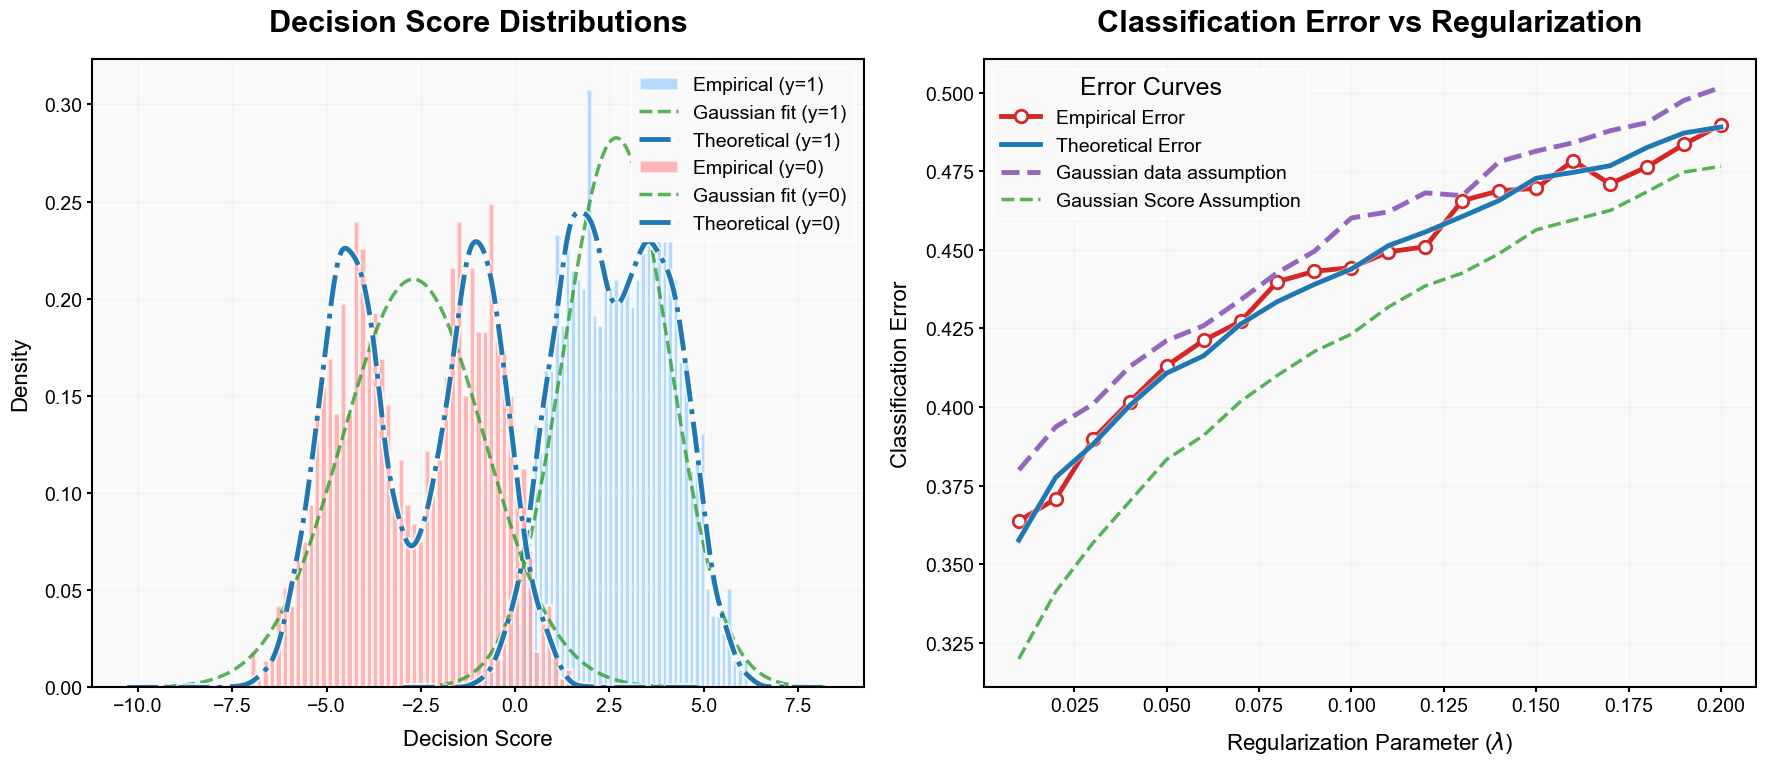

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.neighbors import KernelDensity
from matplotlib import patheffects

# --- Reset font settings for a modern, clean look ---
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

# --- Define a refined, colorblind-friendly palette ---
colors = {
    'background': '#FFFFFF',
    'grid': '#E0E0E0',
    'empirical': '#D62728',    # Deep red
    'theoretical': '#1F77B4',  # Deep blue
    'gaussian_score': '#2CA02C',     # Green
    'gaussian': '#9467BD', # Purple
    'class_0': '#FF9999',      # Light red
    'class_1': '#99CCFF',      # Light blue
    'highlight': '#FF6347',    # Tomato Red
    'accent_line': '#3CB371',  # Medium Sea Green
}

emp_err = np.array(emp_err)
emp_std = np.array(emp_std)
th_err = np.array(th_err)
gauss_err = np.array(gauss_err)

emp_err_gaussian = np.array(emp_err_gaussian)
emp_std_gaussian = np.array(emp_std_gaussian)
th_err_gaussian = np.array(th_err_gaussian)
gauss_err_gaussian = np.array(gauss_err_gaussian)

# --- Create the figure ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=colors['background'])
plt.subplots_adjust(wspace=0.25)

# --- LEFT PANEL: Histograms + PDFs ---
for c_label in classes:
    axes[0].hist(
        scores_emp[c_label],
        bins=50,
        density=True,
        alpha=0.7,
        color=colors['class_0'] if c_label == 0 else colors['class_1'],
        edgecolor='white',
        linewidth=2,
        label=f'Empirical (y={c_label})'
    )
    mu_c = np.mean(scores_th[c_label])
    std_c = np.std(scores_th[c_label])
    x = np.linspace(mu_c - 4 * std_c, mu_c + 4 * std_c, 500)
    axes[0].plot(
        x,
        norm.pdf(x, mu_c, std_c),
        '--',
        color=colors['gaussian_score'],
        linewidth=2.5,
        label=f'Gaussian fit (y={c_label})',
        alpha=0.8
    )
    kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(scores_th[c_label].reshape(-1, 1))
    log_dens = kde.score_samples(x.reshape(-1, 1))
    axes[0].plot(
        x,
        np.exp(log_dens),
        color=colors['theoretical'],
        linewidth=3.5,
        linestyle='-.',
        label=f'Theoretical (y={c_label})',
        path_effects=[patheffects.withStroke(linewidth=6, foreground='white', alpha=0.8)]
    )

axes[0].set_title("Decision Score Distributions", pad=20, fontweight='bold')
axes[0].set_xlabel("Decision Score", labelpad=10)
axes[0].set_ylabel("Density", labelpad=10)
axes[0].legend(loc='upper right', frameon=True, framealpha=1, edgecolor='white')
axes[0].grid(True, linestyle='-', color=colors['grid'], alpha=0.3)

# --- RIGHT PANEL: Classification Error ---
axes[1].plot(
    lam_values,
    emp_err,
    color=colors['empirical'],
    linewidth=3.5,
    label='Empirical Error',
    marker='o',
    markersize=9,
    markerfacecolor='white',
    markeredgewidth=2,
    markeredgecolor=colors['empirical']
)
# axes[1].fill_between(
#     lam_values,
#     emp_err - emp_std,
#     emp_err + emp_std,
#     color=colors['empirical'],
#     alpha=0.15
# )
axes[1].plot(
    lam_values,
    th_err,
    color=colors['theoretical'],
    linewidth=3.5,
    label='Theoretical Error',
    path_effects=[patheffects.withStroke(linewidth=5, foreground='white', alpha=0.5)]
)
axes[1].plot(
    lam_values,
    emp_err_gaussian,
    '--',
    color=colors['gaussian'],
    linewidth=3.5,
    label='Gaussian data assumption',
    markerfacecolor='white',
    markeredgewidth=2,
    markeredgecolor=colors['gaussian']
)
axes[1].plot(
    lam_values,
    gauss_err,
    '--',
    color=colors['gaussian_score'],
    linewidth=2.5,
    label='Gaussian Score Assumption',
    alpha=0.8
)

# --- Styling ---
axes[1].set_title("Classification Error vs Regularization", pad=20, fontweight='bold')
axes[1].set_xlabel("Regularization Parameter ($\lambda$)", labelpad=10)
axes[1].set_ylabel("Classification Error", labelpad=10)
axes[1].legend(loc='upper left', frameon=True, framealpha=0.9, edgecolor='white', title='Error Curves')
axes[1].grid(True, linestyle='-', color=colors['grid'], alpha=0.3)

# --- Save in high quality ---
plt.tight_layout()
fig.savefig("ICML_teaser_figure.pdf", bbox_inches='tight', dpi=1200, transparent=True)
fig.savefig("ICML_teaser_figure.png", bbox_inches='tight', dpi=1200, transparent=True)
plt.show()
